In [53]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Set visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [54]:
# Check the files inside our project data folder

import os

print(os.listdir("DataScience-Task2-UnemploymentAnalysis/data"))

['Unemployment in India.csv']


In [55]:
# Load the unemployment dataset

df = pd.read_csv(
    "DataScience-Task2-UnemploymentAnalysis/data/Unemployment in India.csv"
)

# Display the first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [56]:
# Check the shape of the dataset
print("Number of rows and columns:", df.shape)

# Check the column names
print("\nColumn names:")
print(df.columns)

# Check the data types and non-null values
print("\nDataset information:")
df.info()

Number of rows and columns: (768, 7)

Column names:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    obj

In [57]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values in each column:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Number of duplicate rows:
27


In [58]:
# Clean the dataset

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Remove rows containing missing values
df = df.dropna()

# Remove duplicate rows
df = df.drop_duplicates()

# Reset the index after cleaning
df = df.reset_index(drop=True)

# Check the cleaned dataset
print("Dataset shape after cleaning:", df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(df.duplicated().sum())

Dataset shape after cleaning: (740, 7)

Missing values after cleaning:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Duplicate rows after cleaning:
0


In [59]:
# Convert Date column from text to datetime format

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Check the date range
print("Minimum Date:", df["Date"].min())
print("Maximum Date:", df["Date"].max())

Minimum Date: 2019-05-31 00:00:00
Maximum Date: 2020-06-30 00:00:00


In [60]:
# Display basic statistics of the numerical columns

df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [61]:
# Display the regions available in the dataset

print("Number of regions:", df["Region"].nunique())

print("\nRegions:")
print(df["Region"].unique())

Number of regions: 28

Regions:
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']


## Exploratory Data Analysis

### 1. Region-wise Average Unemployment Rate

To understand how unemployment varies across different regions of India, we calculate the average unemployment rate for each region during the period covered by the dataset.

In [62]:
# Calculate the average unemployment rate for each region

region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

# Display the results
region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

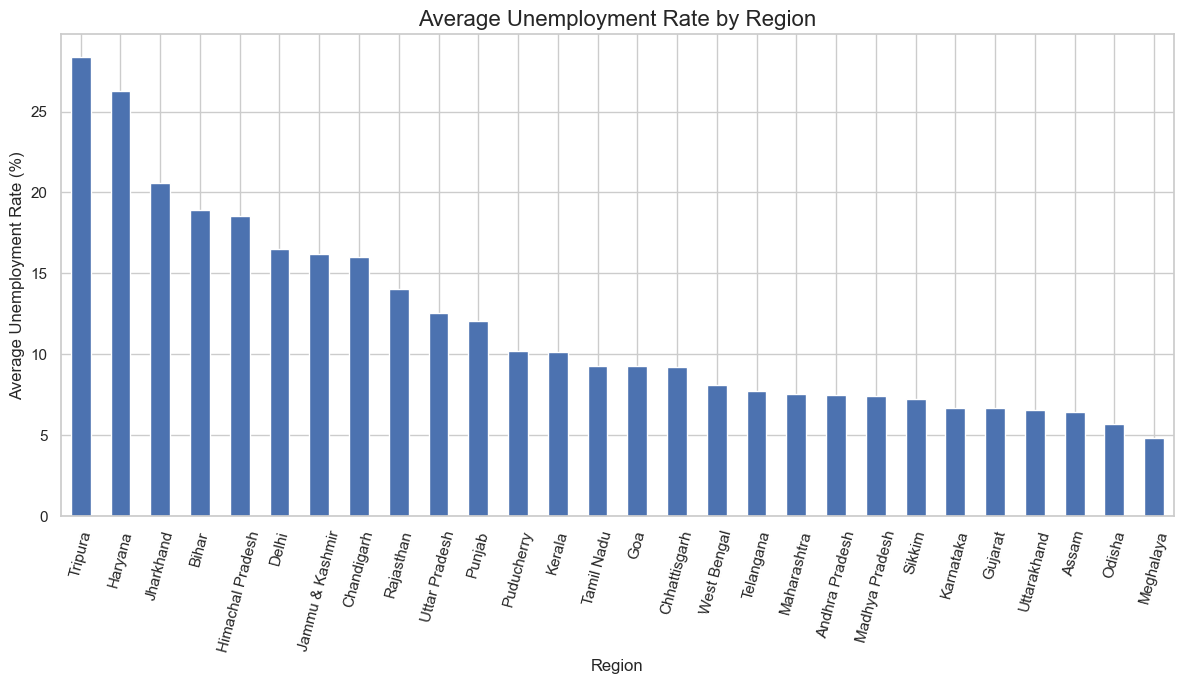

In [63]:
# Visualize average unemployment rate by region

plt.figure(figsize=(12, 7))

region_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Region", fontsize=16)
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

### Observation

The unemployment rate varies quite a lot across different regions. Tripura has the highest average unemployment rate at around 28.35%, followed by Haryana at about 26.28% and Jharkhand at around 20.59%.

On the other hand, Meghalaya, Odisha and Assam have comparatively lower average unemployment rates. Maharashtra has an average unemployment rate of about 7.56% during the period covered by the dataset.

Overall, the chart shows that unemployment conditions were not the same across India, with some regions experiencing much higher unemployment than others.


## 2. Month-wise Unemployment Trend

To understand how unemployment changed over time, we calculate the average unemployment rate for each month across all regions in the dataset.

In [64]:
# Calculate the average unemployment rate for each month

monthly_avg = (
    df.groupby(df["Date"].dt.to_period("M"))["Estimated Unemployment Rate (%)"]
    .mean()
)

# Display the monthly averages
monthly_avg

Date
2019-05     8.874259
2019-06     9.303333
2019-07     9.033889
2019-08     9.637925
2019-09     9.051731
2019-10     9.900909
2019-11     9.868364
2019-12     9.497358
2020-01     9.950755
2020-02     9.964717
2020-03    10.700577
2020-04    23.641569
2020-05    24.875294
2020-06    11.903600
Freq: M, Name: Estimated Unemployment Rate (%), dtype: float64

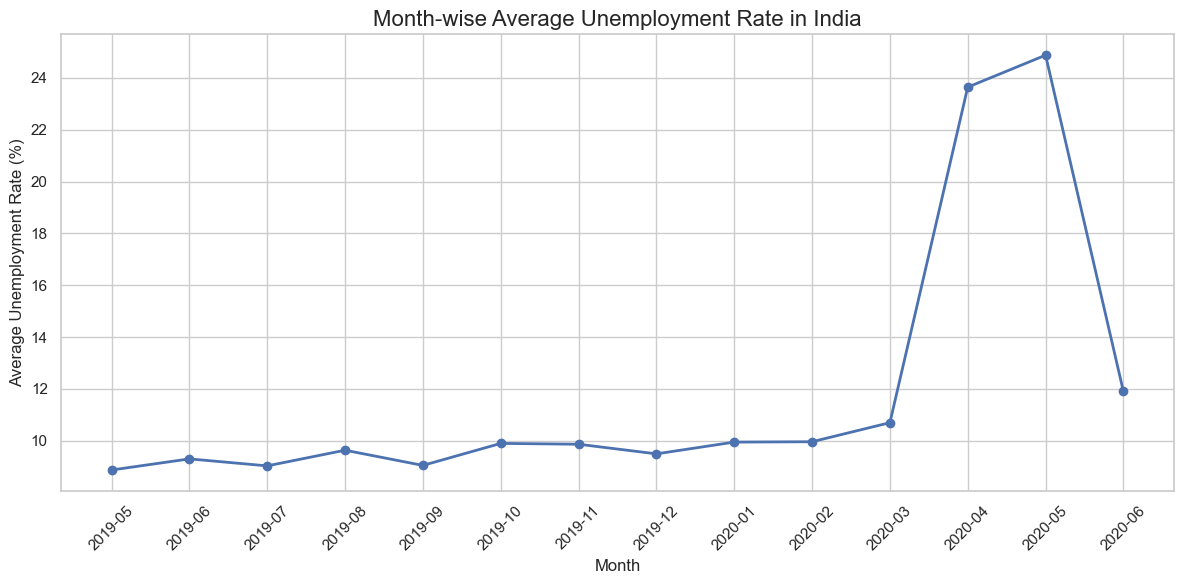

In [65]:
# Plot the month-wise unemployment trend

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_avg.index.astype(str),
    monthly_avg.values,
    marker="o",
    linewidth=2
)

plt.title("Month-wise Average Unemployment Rate in India", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The unemployment rate remained fairly stable from May 2019 to March 2020, staying mostly around 9% to 12%. However, there was a sharp increase in unemployment during April and May 2020.

The unemployment rate reached its highest level in May 2020 at around 24%, which shows a major disruption in employment conditions during the COVID-19 period. In June 2020, the rate dropped considerably to around 13%, suggesting some improvement compared with the previous two months.

Overall, the trend shows a relatively stable unemployment situation before COVID-19, followed by a sudden rise during the early months of the pandemic.

## 3. Time-Series Analysis of Selected Regions

To compare unemployment patterns across different regions, we examine the monthly unemployment rates of Maharashtra, Haryana, and Tamil Nadu.

A time-series comparison helps us understand how unemployment changed in these regions over the study period, especially during the COVID-19 period.

In [66]:
# Select three regions for time-series comparison

selected_regions = ["Maharashtra", "Haryana", "Tamil Nadu"]

region_data = df[df["Region"].isin(selected_regions)]

# Calculate monthly average unemployment rate for each selected region
region_monthly = (
    region_data
    .groupby(["Date", "Region"])["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

region_monthly.head()

,Date,Region,Estimated Unemployment Rate (%)
0,2019-05-31,Haryana,19.605
1,2019-05-31,Maharashtra,4.875
2,2019-05-31,Tamil Nadu,0.930
3,2019-06-30,Haryana,21.750
4,2019-06-30,Maharashtra,5.400


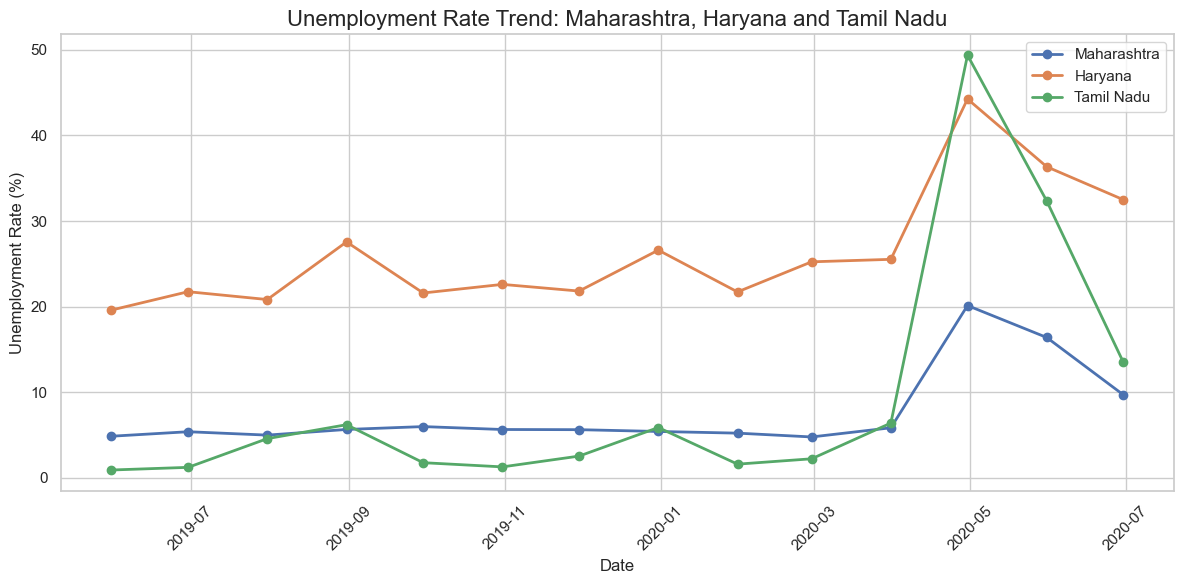

In [67]:
# Plot unemployment trends for the three selected regions

plt.figure(figsize=(12, 6))

for region in selected_regions:
    data = region_monthly[region_monthly["Region"] == region]
    
    plt.plot(
        data["Date"],
        data["Estimated Unemployment Rate (%)"],
        marker="o",
        linewidth=2,
        label=region
    )

plt.title("Unemployment Rate Trend: Maharashtra, Haryana and Tamil Nadu", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The three regions show noticeably different unemployment patterns during the study period. Haryana consistently recorded a higher unemployment rate than Maharashtra and Tamil Nadu for most of the period.

Maharashtra remained relatively stable, with unemployment generally staying below 10% before the COVID-19 period. Tamil Nadu also had comparatively lower unemployment rates, although it showed a sharp increase during May 2020.

The impact of COVID-19 is particularly visible in May 2020, when unemployment increased sharply in all three regions. Tamil Nadu experienced the highest spike, reaching around 47%, while Haryana reached around 42% and Maharashtra around 21%.

By June 2020, unemployment rates started to decline in all three regions, although they remained higher than their pre-COVID levels.

## 4. Top 10 Regions with Highest Average Unemployment Rate

To identify the regions with the highest unemployment levels during the study period, we select the top 10 regions based on their average unemployment rate.

In [68]:
# Select the top 10 regions with the highest average unemployment rate

top_10 = region_avg.head(10)

# Display the results
top_10

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

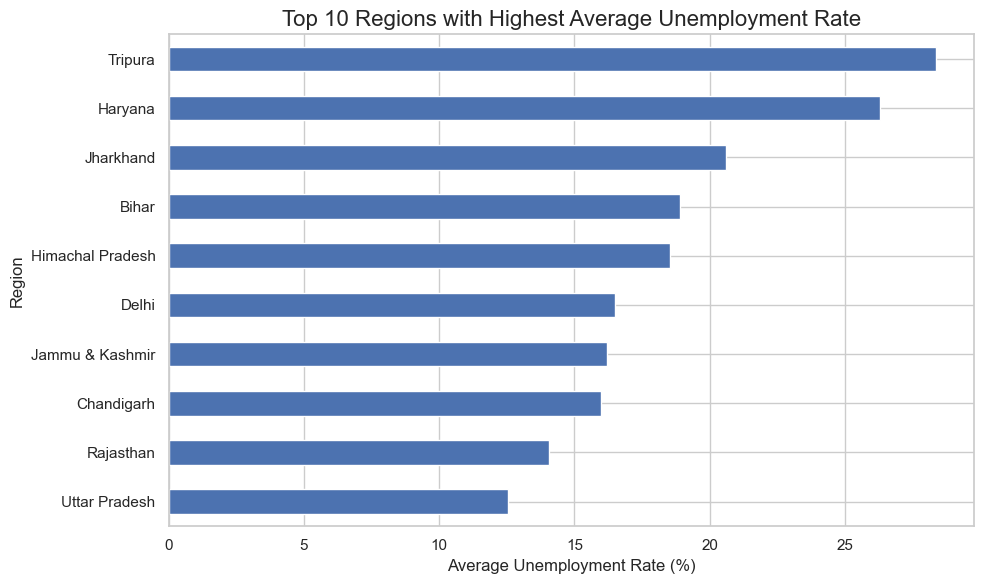

In [69]:
# Visualize the top 10 regions with the highest average unemployment rate

plt.figure(figsize=(10, 6))

top_10.sort_values().plot(kind="barh")

plt.title("Top 10 Regions with Highest Average Unemployment Rate", fontsize=16)
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

Observation:
The chart shows that Tripura has the highest average unemployment rate among all the regions in the dataset, followed by Haryana and Jharkhand. Bihar and Himachal Pradesh also show relatively high unemployment rates. On the other hand, regions such as Uttar Pradesh and Rajasthan have lower average rates compared with the top three. Overall, the chart shows that unemployment levels vary considerably across different regions of India.

## 4. Correlation Analysis

Correlation analysis helps us understand the relationship between unemployment, employment, and labour participation rates.

In [70]:
# Select the columns needed for correlation analysis
correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


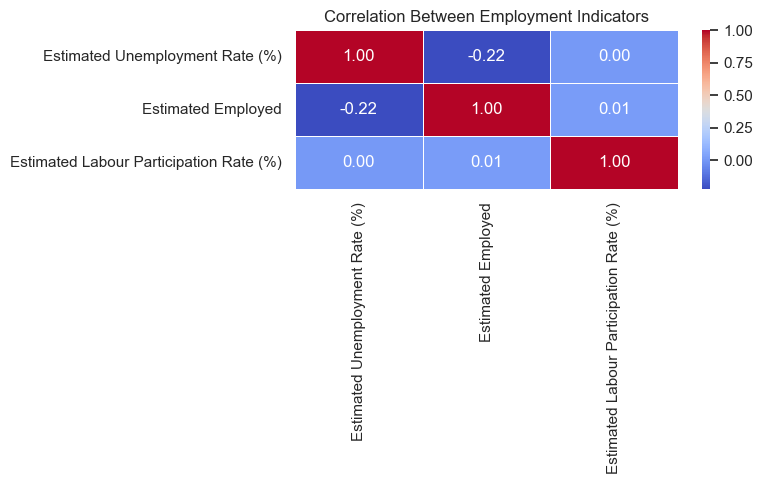

In [71]:
# Plot the correlation heatmap
plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Employment Indicators")
plt.tight_layout()
plt.show()

### Observation

The correlation analysis shows a weak negative relationship (-0.22) between the unemployment rate and the estimated number of employed people. This suggests that the two variables move slightly in opposite directions, but the relationship is not strong.

The correlation between unemployment rate and labour participation rate is almost zero (0.00), indicating very little linear relationship between them in this dataset. Similarly, the estimated employed population and labour participation rate have almost no correlation (0.01).

Overall, the correlations are weak, which suggests that unemployment, employment and labour participation are influenced by several factors rather than having a strong direct linear relationship with each other.

## 5. Pre-COVID vs COVID-19 Period Analysis

The dataset covers the period from May 2019 to June 2020. To understand the impact of the COVID-19 period on employment indicators, the data is divided into two periods:

- **Pre-COVID:** May 2019 to February 2020
- **COVID Period:** March 2020 to June 2020

The average unemployment rate, estimated employment, and labour participation rate are compared between these two periods.

In [72]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

print("Minimum date:", df["Date"].min())
print("Maximum date:", df["Date"].max())

Minimum date: 2019-05-31 00:00:00
Maximum date: 2020-06-30 00:00:00


In [73]:
pre_covid = df[df["Date"] < "2020-03-01"]

covid_period = df[
    (df["Date"] >= "2020-03-01") &
    (df["Date"] <= "2020-06-30")
]

print("Pre-COVID records:", len(pre_covid))
print("COVID period records:", len(covid_period))

Pre-COVID records: 536
COVID period records: 204


In [74]:
comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "COVID Period"],

    "Average Unemployment Rate (%)": [
        pre_covid["Estimated Unemployment Rate (%)"].mean(),
        covid_period["Estimated Unemployment Rate (%)"].mean()
    ],

    "Average Estimated Employed": [
        pre_covid["Estimated Employed"].mean(),
        covid_period["Estimated Employed"].mean()
    ],

    "Average Labour Participation Rate (%)": [
        pre_covid["Estimated Labour Participation Rate (%)"].mean(),
        covid_period["Estimated Labour Participation Rate (%)"].mean()
    ]
})

comparison

,Period,Average Unemployment Rate (%),Average Estimated Employed,Average Labour Participation Rate (%)
0,Pre-COVID,9.509534,7.466028e+06,43.886119
1,COVID Period,17.774363,6.517203e+06,39.330049


### Observation

The data shows a clear change in India's employment situation during the COVID-19 period. The average unemployment rate increased from around 9.51% before COVID-19 to 17.77% during the COVID period.

At the same time, the average estimated number of employed people decreased from approximately 7.47 million to 6.52 million. The labour participation rate also decreased from 43.89% to 39.33%.

Overall, the results show that the COVID-19 period was associated with higher unemployment, lower estimated employment, and lower labour force participation in the dataset.

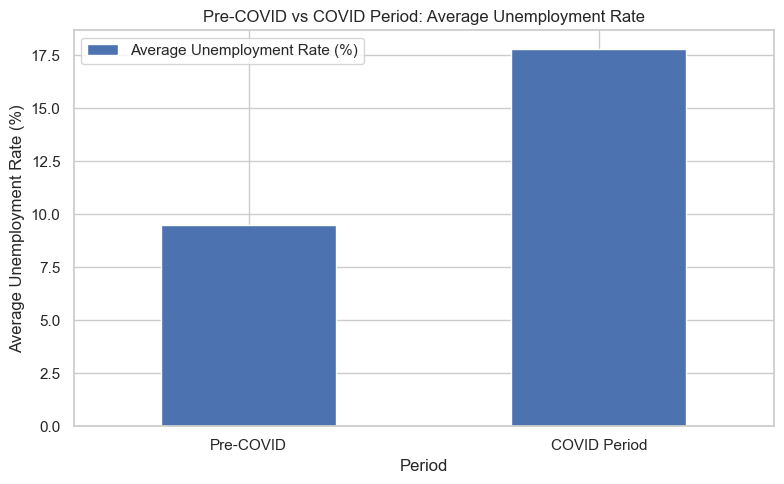

In [75]:
unemployment_comparison = comparison.set_index("Period")[
    ["Average Unemployment Rate (%)"]
]

unemployment_comparison.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Pre-COVID vs COVID Period: Average Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

The average unemployment rate increased substantially during the COVID-19 period. It rose from approximately 9.51% before COVID-19 to 17.77% during the COVID period, indicating a major deterioration in employment conditions.

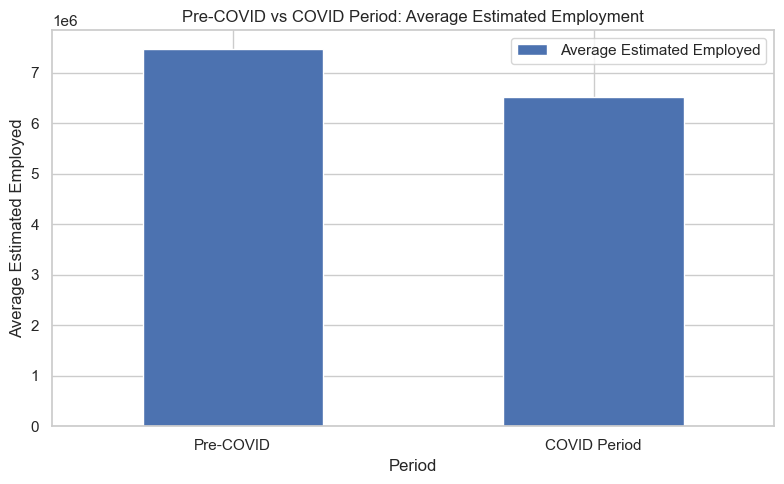

In [76]:
employment_comparison = comparison.set_index("Period")[
    ["Average Estimated Employed"]
]

employment_comparison.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Pre-COVID vs COVID Period: Average Estimated Employment")
plt.xlabel("Period")
plt.ylabel("Average Estimated Employed")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

The average estimated number of employed people decreased during the COVID-19 period. It fell from approximately 7.47 million before COVID-19 to 6.52 million during the COVID period, showing a decline in estimated employment.

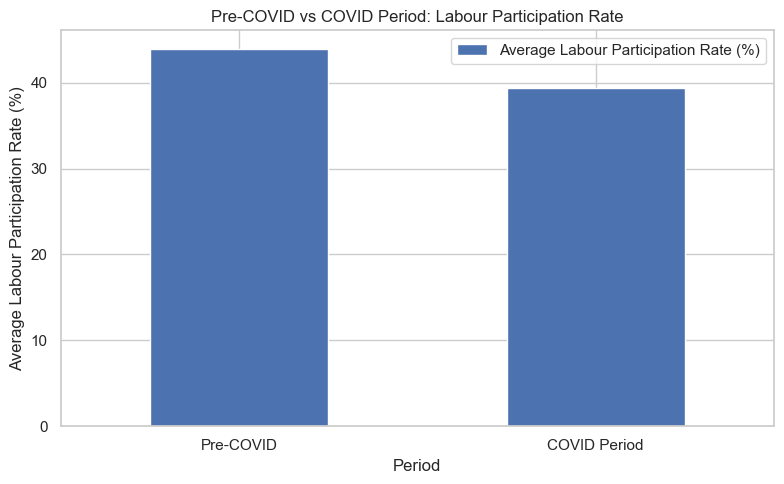

In [77]:
labour_comparison = comparison.set_index("Period")[
    ["Average Labour Participation Rate (%)"]
]

labour_comparison.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Pre-COVID vs COVID Period: Labour Participation Rate")
plt.xlabel("Period")
plt.ylabel("Average Labour Participation Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

The average labour participation rate decreased during the COVID-19 period. It declined from approximately 43.89% before COVID-19 to 39.33% during the COVID period, indicating a reduction in labour force participation.

## 6. Key Findings and Conclusion

### Key Findings

- Unemployment rates varied considerably across different regions of India.
- Tripura recorded the highest average unemployment rate among the regions in the dataset.
- The overall unemployment rate remained relatively stable before COVID-19 but increased sharply during April and May 2020.
- Haryana generally recorded higher unemployment than Maharashtra and Tamil Nadu during the study period.
- The COVID-19 period was associated with a significant increase in the average unemployment rate, from approximately 9.51% to 17.77%.
- Average estimated employment decreased from approximately 7.47 million before COVID-19 to 6.52 million during the COVID period.
- Labour participation also decreased from approximately 43.89% to 39.33% during the COVID period.
- The correlation analysis showed weak relationships among unemployment, estimated employment, and labour participation.

### Conclusion

This analysis shows that unemployment conditions varied significantly across different regions of India. The COVID-19 period was associated with a clear deterioration in employment conditions, with unemployment increasing while estimated employment and labour participation decreased. The visualizations and statistical comparisons help highlight the regional and temporal changes in India's unemployment situation during the period covered by the dataset.